In [1]:
#hide
options(jupyter.plot_scale=3)
options(repr.plot.width=6,repr.plot.height=6,repr.plot.res=300)

# (노트) 분류분석 (3)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈
- hide: false
- categories: [ADsP]

### 토익, 학점 --> 합격 

In [2]:
토익=c(300,350,400,450,
     500,550,500,550,
     750,700,750,700,
     950)
학점=c(1,2,1,2,
     2,3,2,2,
     3,4,4,4,
     0.5)
합격=c(0,0,0,0,
     0,1,1,0,
     1,1,1,1,
     1)

In [3]:
X = cbind(토익,학점)
y = 합격

In [4]:
데이터 = cbind(X,y)
데이터 

토익,학점,y
300,1.0,0
350,2.0,0
400,1.0,0
450,2.0,0
500,2.0,0
550,3.0,1
500,2.0,1
550,2.0,0
750,3.0,1
700,4.0,1


### 로지스틱 회귀분석

`-` `합격 = b0 + 토익*b1 + 학점*b2` 를 만족하는 적절한 b0, b1, b2를 구하고 싶음 --> 회귀모형이네

In [5]:
lm(합격 ~ 토익+학점)


Call:
lm(formula = 합격 ~ 토익 + 학점)

Coefficients:
(Intercept)         토익         학점  
   -0.84379      0.00181      0.14707  


In [6]:
b0= -1.1914414
b1= 0.0007207
b2= 0.4099099  

- 모형: `합격 = b0 + 토익*b1 + 학점*b2`

확인해보자. 

In [7]:
X

토익,학점
300,1.0
350,2.0
400,1.0
450,2.0
500,2.0
550,3.0
500,2.0
550,2.0
750,3.0
700,4.0


In [8]:
b0 + 300*b1 + 2*b2 # 1번관측치가 합격할 확률 (음수우..?)

[1] -0.1554116

In [9]:
b0 + 700*b1 + 4*b2 # 마지막관측치가 합격할 확률

[1] 0.9526882

`-` 관찰: 학생들의 학점,토익점수를 넣기만 하면 확률이 예측되는군? 

`-` 학점 4.5, 토익 995를 대입해보자. --> 합격확률은 거의 1

In [10]:
b0 + 995*b1 + 4.5*b2

[1] 1.37025

`-` 1이 넘는다? $\to$ 음수도 안나오고 1도 안넘었으면 좋겠는데? 

`-` 로지스틱이라는걸 만들자. 

`-` X에 시그모이드를 취하자. 그러면 모형은

```
분자 = 1+exp(b0 + 토익*b1 + 학점*b2)
분모 = exp(b0 + 토익*b1 + 학점*b2)
합격 = 분모/분자 
```

식으로 쓰면 

$$y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}=\frac{1}{1+\exp(-b_0-b_1X_1-b_2X_2)}$$ 

`-` 넣어보자. 

In [11]:
분자_ =exp(b0 + 995*b1 + 4.5*b2)
분모_ =exp(b0 + 995*b1 + 4.5*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.7974205

- 0~1사이로 떨어지김함. 그런데 토익995에 학점 4.5인데 합격률이 너무 낮음 

`-` 다른 학생을 넣어보자. 

In [12]:
분자_=exp(b0 + 700*b1 + 4*b2)
분모_=exp(b0 + 700*b1 + 4*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.7216555

`-` 역시 좀 낮다? --> 사실 이건 모형이 $y \approx b_0 + b_1 X_1 + b_2X_2$ 라고 생각하고 찾은 최적의 $b_0,b_1,b_2$임. $y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}$ 이걸 가정한건 아니었다


`-` 애초에 $y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}$를 가정하면 계수를 찾으면 좀 다를수 있음. 실제로 다름. 

`-` 그걸해보자. --> lm이 아니라 glm 이용 

In [13]:
glm(합격 ~ 토익+학점)


Call:  glm(formula = 합격 ~ 토익 + 학점)

Coefficients:
(Intercept)         토익         학점  
   -0.84379      0.00181      0.14707  

Degrees of Freedom: 12 Total (i.e. Null);  10 Residual
Null Deviance:	    3.231 
Residual Deviance: 1.023 	AIC: 11.85

`-` 이건 아까 회귀랑 똑같음. glm만 쓰면 되는게 아니라 아래와 같이 해야함 

In [14]:
glm(합격 ~ 토익+학점,family=binomial)


Call:  glm(formula = 합격 ~ 토익 + 학점, family = binomial)

Coefficients:
(Intercept)         토익         학점  
  -17.92394      0.02081      3.18837  

Degrees of Freedom: 12 Total (i.e. Null);  10 Residual
Null Deviance:	    17.94 
Residual Deviance: 5.079 	AIC: 11.08

`-` 다시 넣어보자. 

In [15]:
b0=-13.5848
b1= 0.0149   
b2= 2.5694 
분자_=exp(b0 + 700*b1 + 3.0*b2)
분모_=exp(b0 + 700*b1 + 3.0*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.9895784

In [16]:
분자_=exp(b0 + 995*b1 + 4.5*b2)
분모_=exp(b0 + 995*b1 + 4.5*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.9999972

- 상당히 그럴듯함 

`-` 해석이 가능함: 토익 700, 학점 4.0인 학생이 토익을 995로 올리고 학점을 4.5로 높이면 합격률이 98 -> 99로 상승 

#### 의사결정나무 

`-` 의사결정나무로 분석해보자. rpart로드 

In [17]:
library(rpart)

`-` 현재합격변수

In [18]:
합격

[1] 0 0 0 0 0 1 1 0 1 1 1 1 1

- 이게 입력으로가면 범주로 봐야하나 숫자로 봐야하나? (트리는 y가 연속이어도 가능하고 종속이어도 가능하므로 이렇게 종속변수를 넣으면 컴퓨터가 헷갈려함)

`-` 변수를 명확하게 범주형으로 바꾸자. 

In [19]:
합격2 =  c('불합격','불합격','불합격','불합격','불합격','합격','합격','불합격','합격','합격','합격','합격','합격') # 트리는 y가 연속이어도가능하고 종속이어도 가능하므로 y를 0,1로 넣으면 이걸 연속형으로 착각한다. 그래서 바꿔줌

`-` 의사결정나무 분석 

In [20]:
의사결정나무결과 = rpart(합격2 ~ 토익 + 학점)
의사결정나무결과

n= 13 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 13 6 합격 (0.4615385 0.5384615) *

- 아무것도 가지가 안생겼다? 

`-` 의사결정나무 특징: 데이터가 어느정도 있어야 돌아감. (정지규칙때문) 

In [21]:
합격3=rep(합격2,30)
토익2=rep(토익,30)
학점2=rep(학점,30)

In [22]:
length(합격3)

[1] 390

In [23]:
부먹=sample(c('부먹','찍먹'),size=390,replace=T)
민초=sample(c('먹','안먹'),size=390,replace=T)
주민번호끝자리=sample(c('홀','짝'),size=390,replace=T)
학번끝자리=sample(c('홀','짝'),size=390,replace=T)
더미1=sample(c('홀','짝'),size=390,replace=T)
더미2=sample(c('홀','짝'),size=390,replace=T)
더미3=sample(c('홀','짝'),size=390,replace=T)
더미4=sample(c('홀','짝'),size=390,replace=T)
더미5=sample(c('홀','짝'),size=390,replace=T)
더미6=sample(c('홀','짝'),size=390,replace=T)

In [24]:
데이터2=data.frame(합격=합격3,
                토익=토익2,
                학점=학점2,
                부먹=부먹,
                민초=민초,
                주민번호끝자리=주민번호끝자리,
                학번끝자리=학번끝자리,
                더미1=더미1,
                더미2=더미2,
                더미3=더미3,
                더미4=더미4,
                더미5=더미5,
                더미6=더미6)
데이터2

합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
불합격,300,1.0,찍먹,먹,홀,홀,짝,홀,짝,짝,홀,홀
불합격,350,2.0,찍먹,안먹,홀,짝,짝,홀,홀,홀,짝,짝
불합격,400,1.0,찍먹,먹,짝,짝,짝,짝,홀,짝,홀,짝
불합격,450,2.0,찍먹,먹,짝,홀,짝,짝,홀,짝,홀,홀
불합격,500,2.0,찍먹,안먹,짝,홀,홀,홀,홀,홀,짝,홀
합격,550,3.0,부먹,먹,짝,홀,홀,짝,홀,홀,짝,홀
합격,500,2.0,찍먹,안먹,짝,짝,홀,짝,짝,홀,홀,홀
불합격,550,2.0,부먹,안먹,짝,짝,홀,홀,짝,짝,홀,홀
합격,750,3.0,부먹,안먹,홀,짝,짝,홀,홀,홀,홀,홀


`-` 이제돌려보자. 

In [25]:
의사결정나무결과=rpart(data=데이터2, 합격~.)
의사결정나무결과

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 390 180 합격 (0.4615385 0.5384615)  
   2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
     4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571)  
       8) 토익< 475 120   0 불합격 (1.0000000 0.0000000) *
       9) 토익>=475 90  30 불합격 (0.6666667 0.3333333)  
        18) 토익>=525 30   0 불합격 (1.0000000 0.0000000) *
        19) 토익< 525 60  30 불합격 (0.5000000 0.5000000)  
          38) 더미3=짝 31  12 불합격 (0.6129032 0.3870968) *
          39) 더미3=홀 29  11 합격 (0.3793103 0.6206897)  
            78) 민초=안먹 12   4 불합격 (0.6666667 0.3333333) *
            79) 민초=먹 17   3 합격 (0.1764706 0.8235294) *
     5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
   3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

`-` 결과보기 너무 힘드니까 그림으로 그리자 

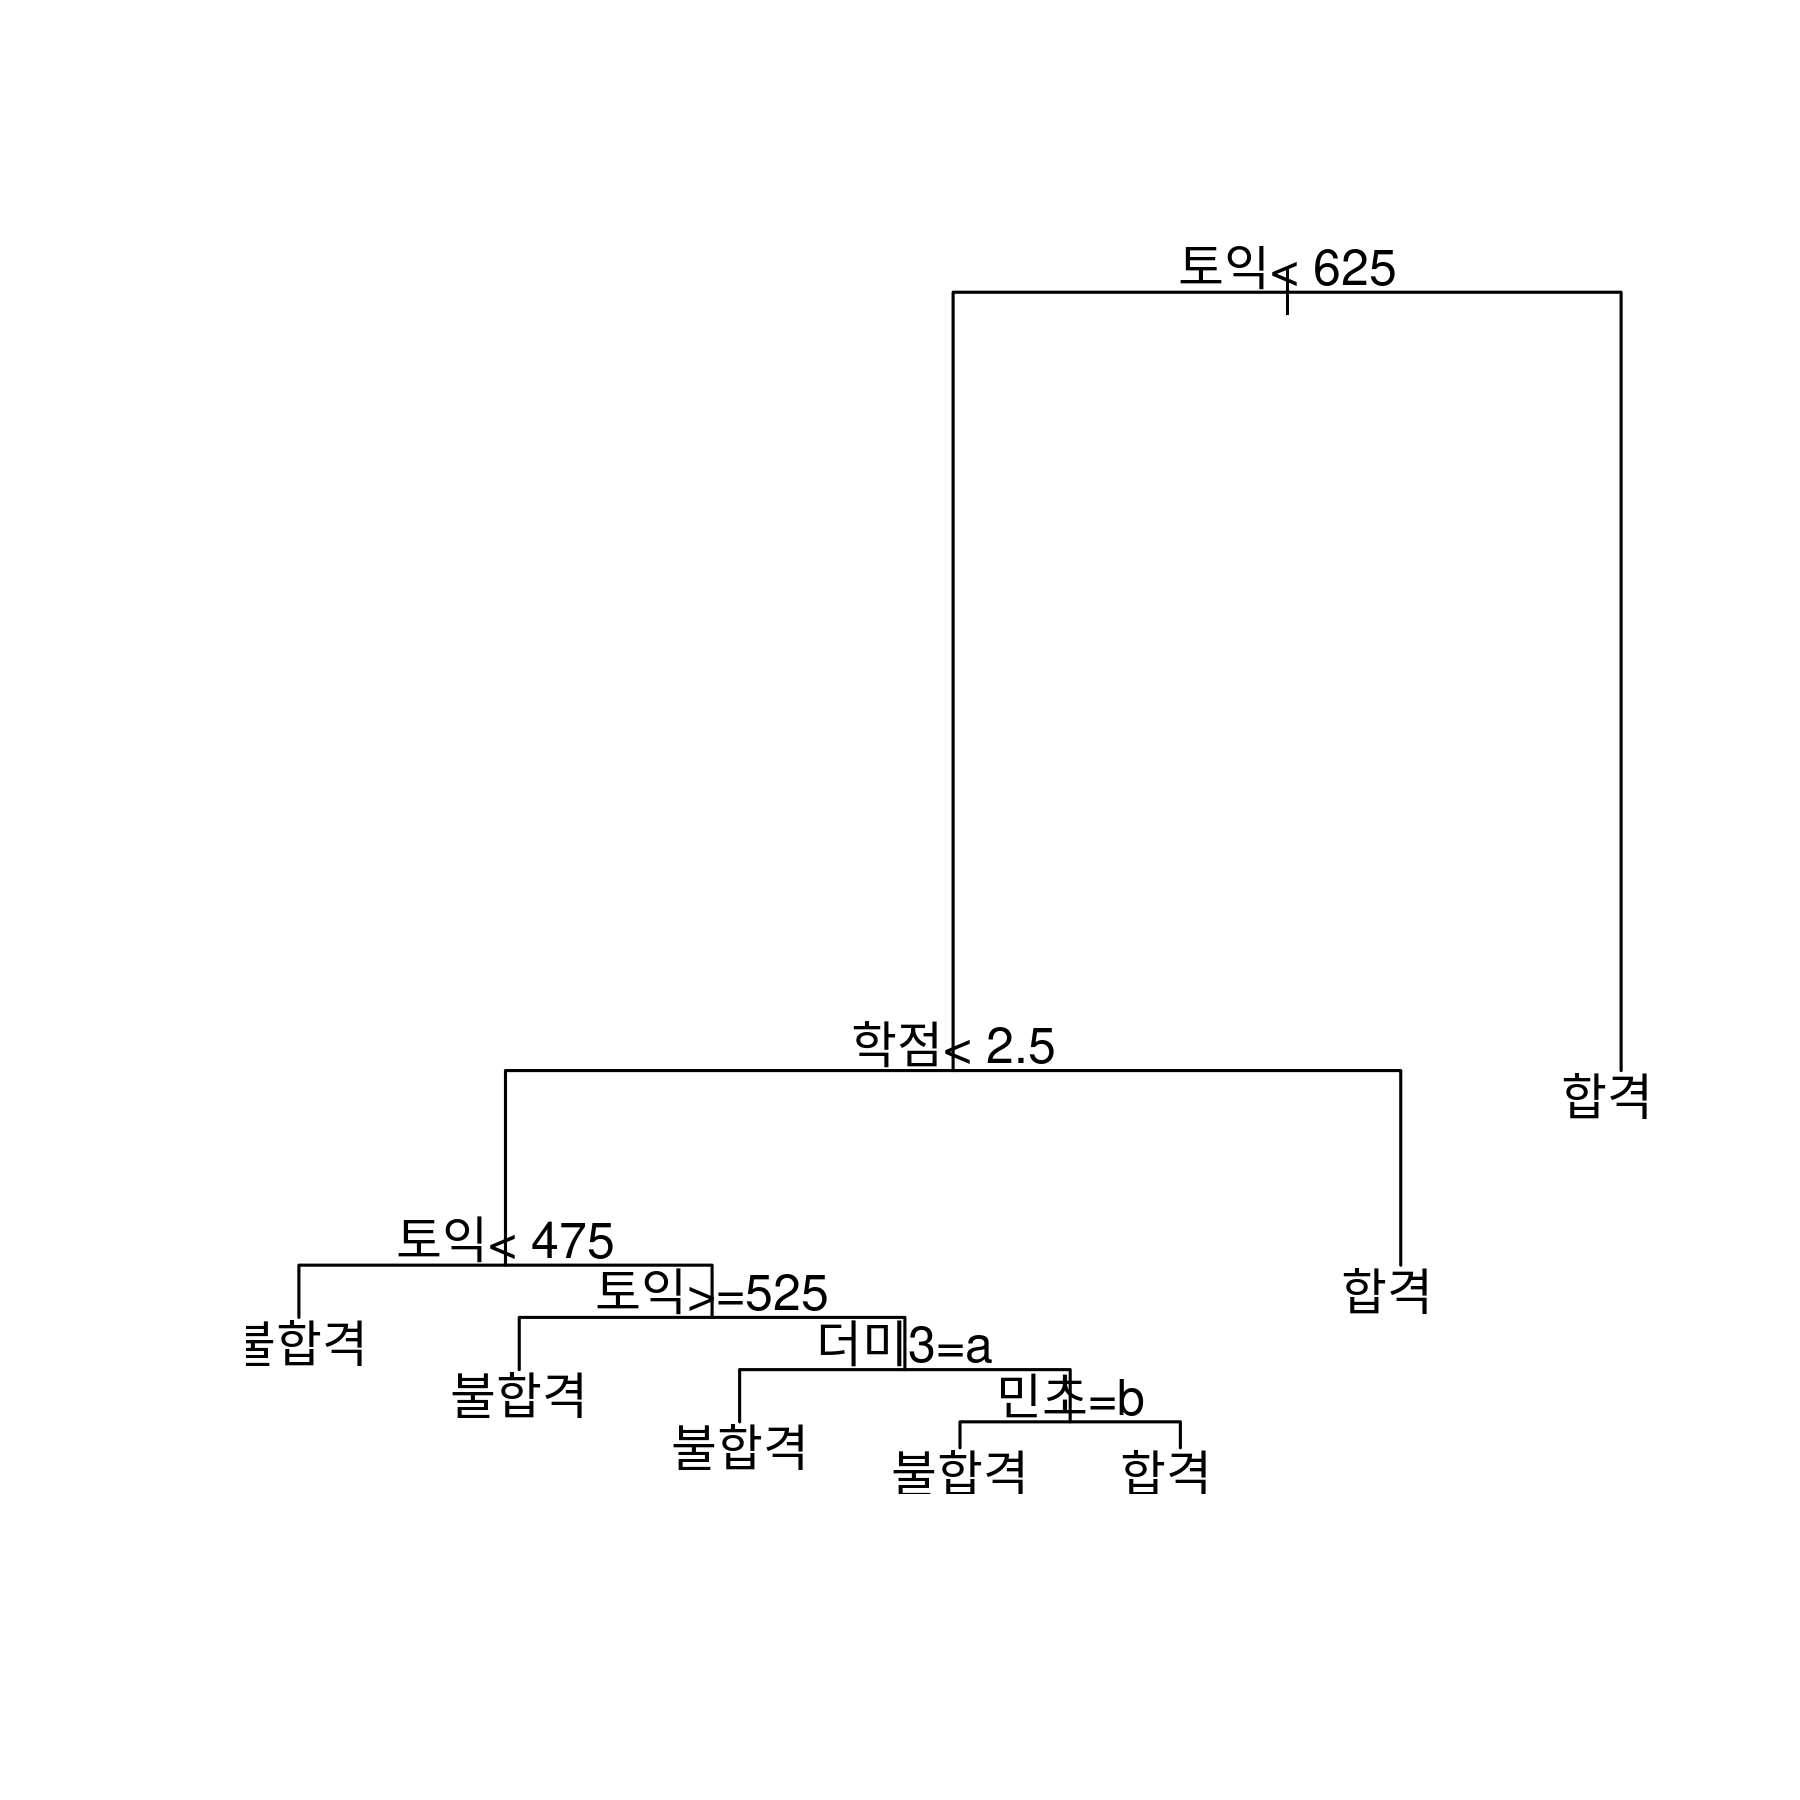

In [26]:
plot(의사결정나무결과)
text(의사결정나무결과)

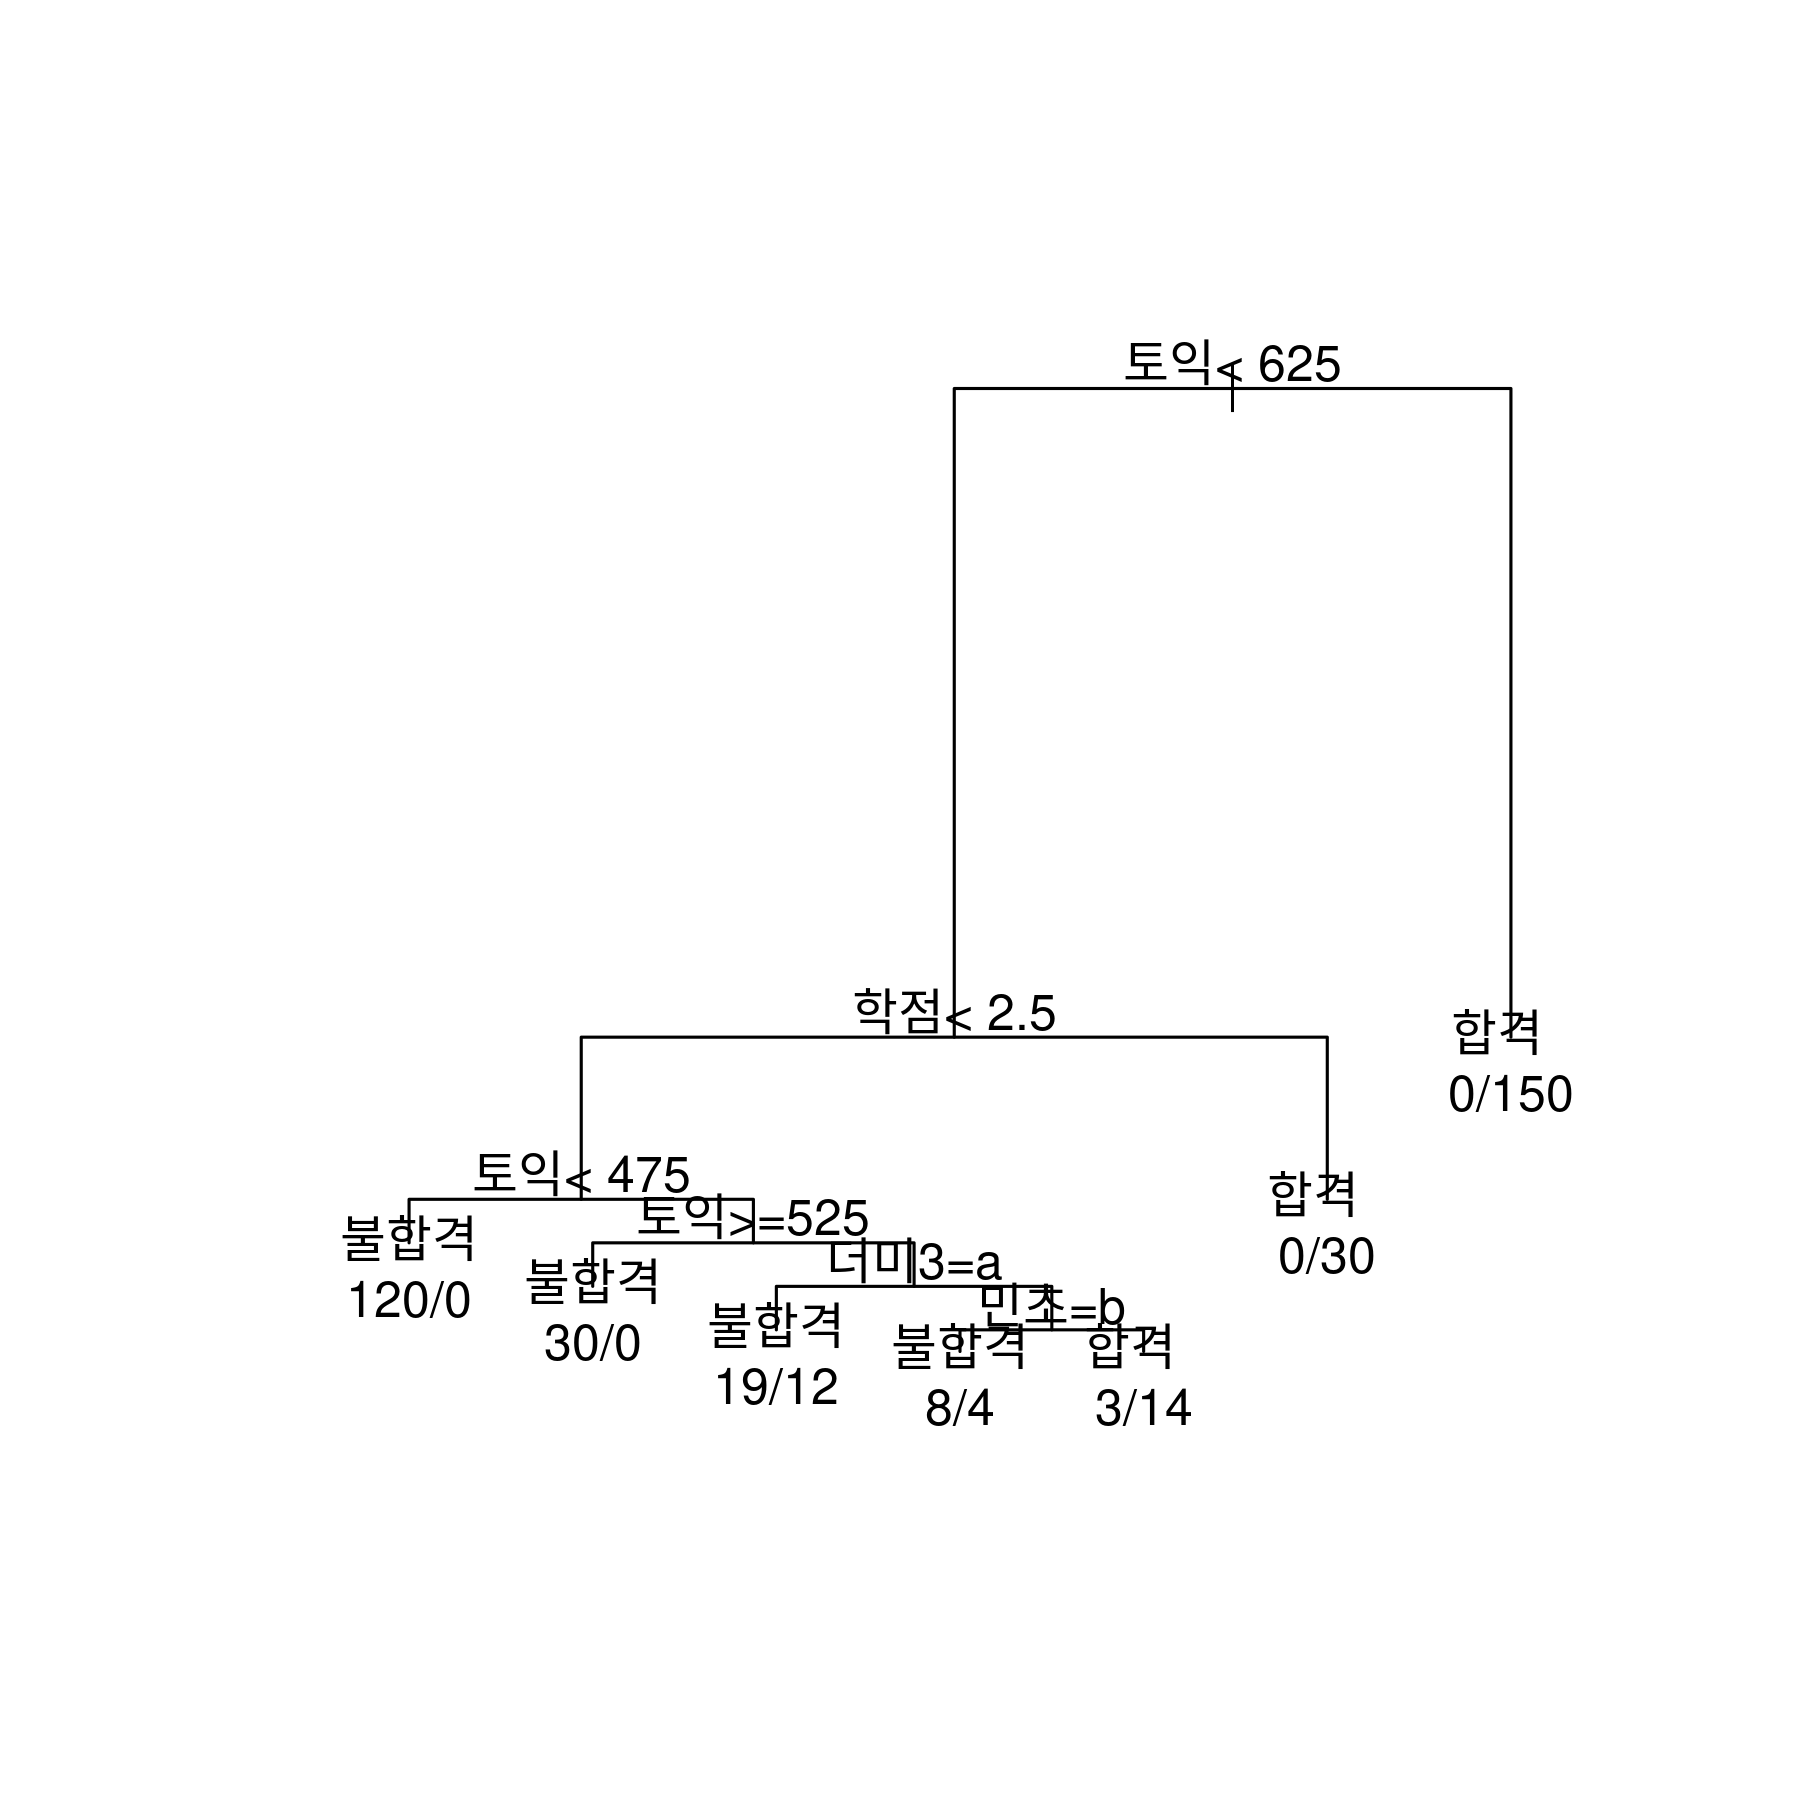

In [27]:
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 더미변수로 분류하고 있음.. $\to$ 오버핏 

`-` 가지치기

In [28]:
prune(의사결정나무결과,cp=0.1) ## cp=얼마나 가지를 칠지결정함, cp가 클수록 가지를 많이침 

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 390 180 합격 (0.4615385 0.5384615)  
  2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
    4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571) *
    5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
  3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

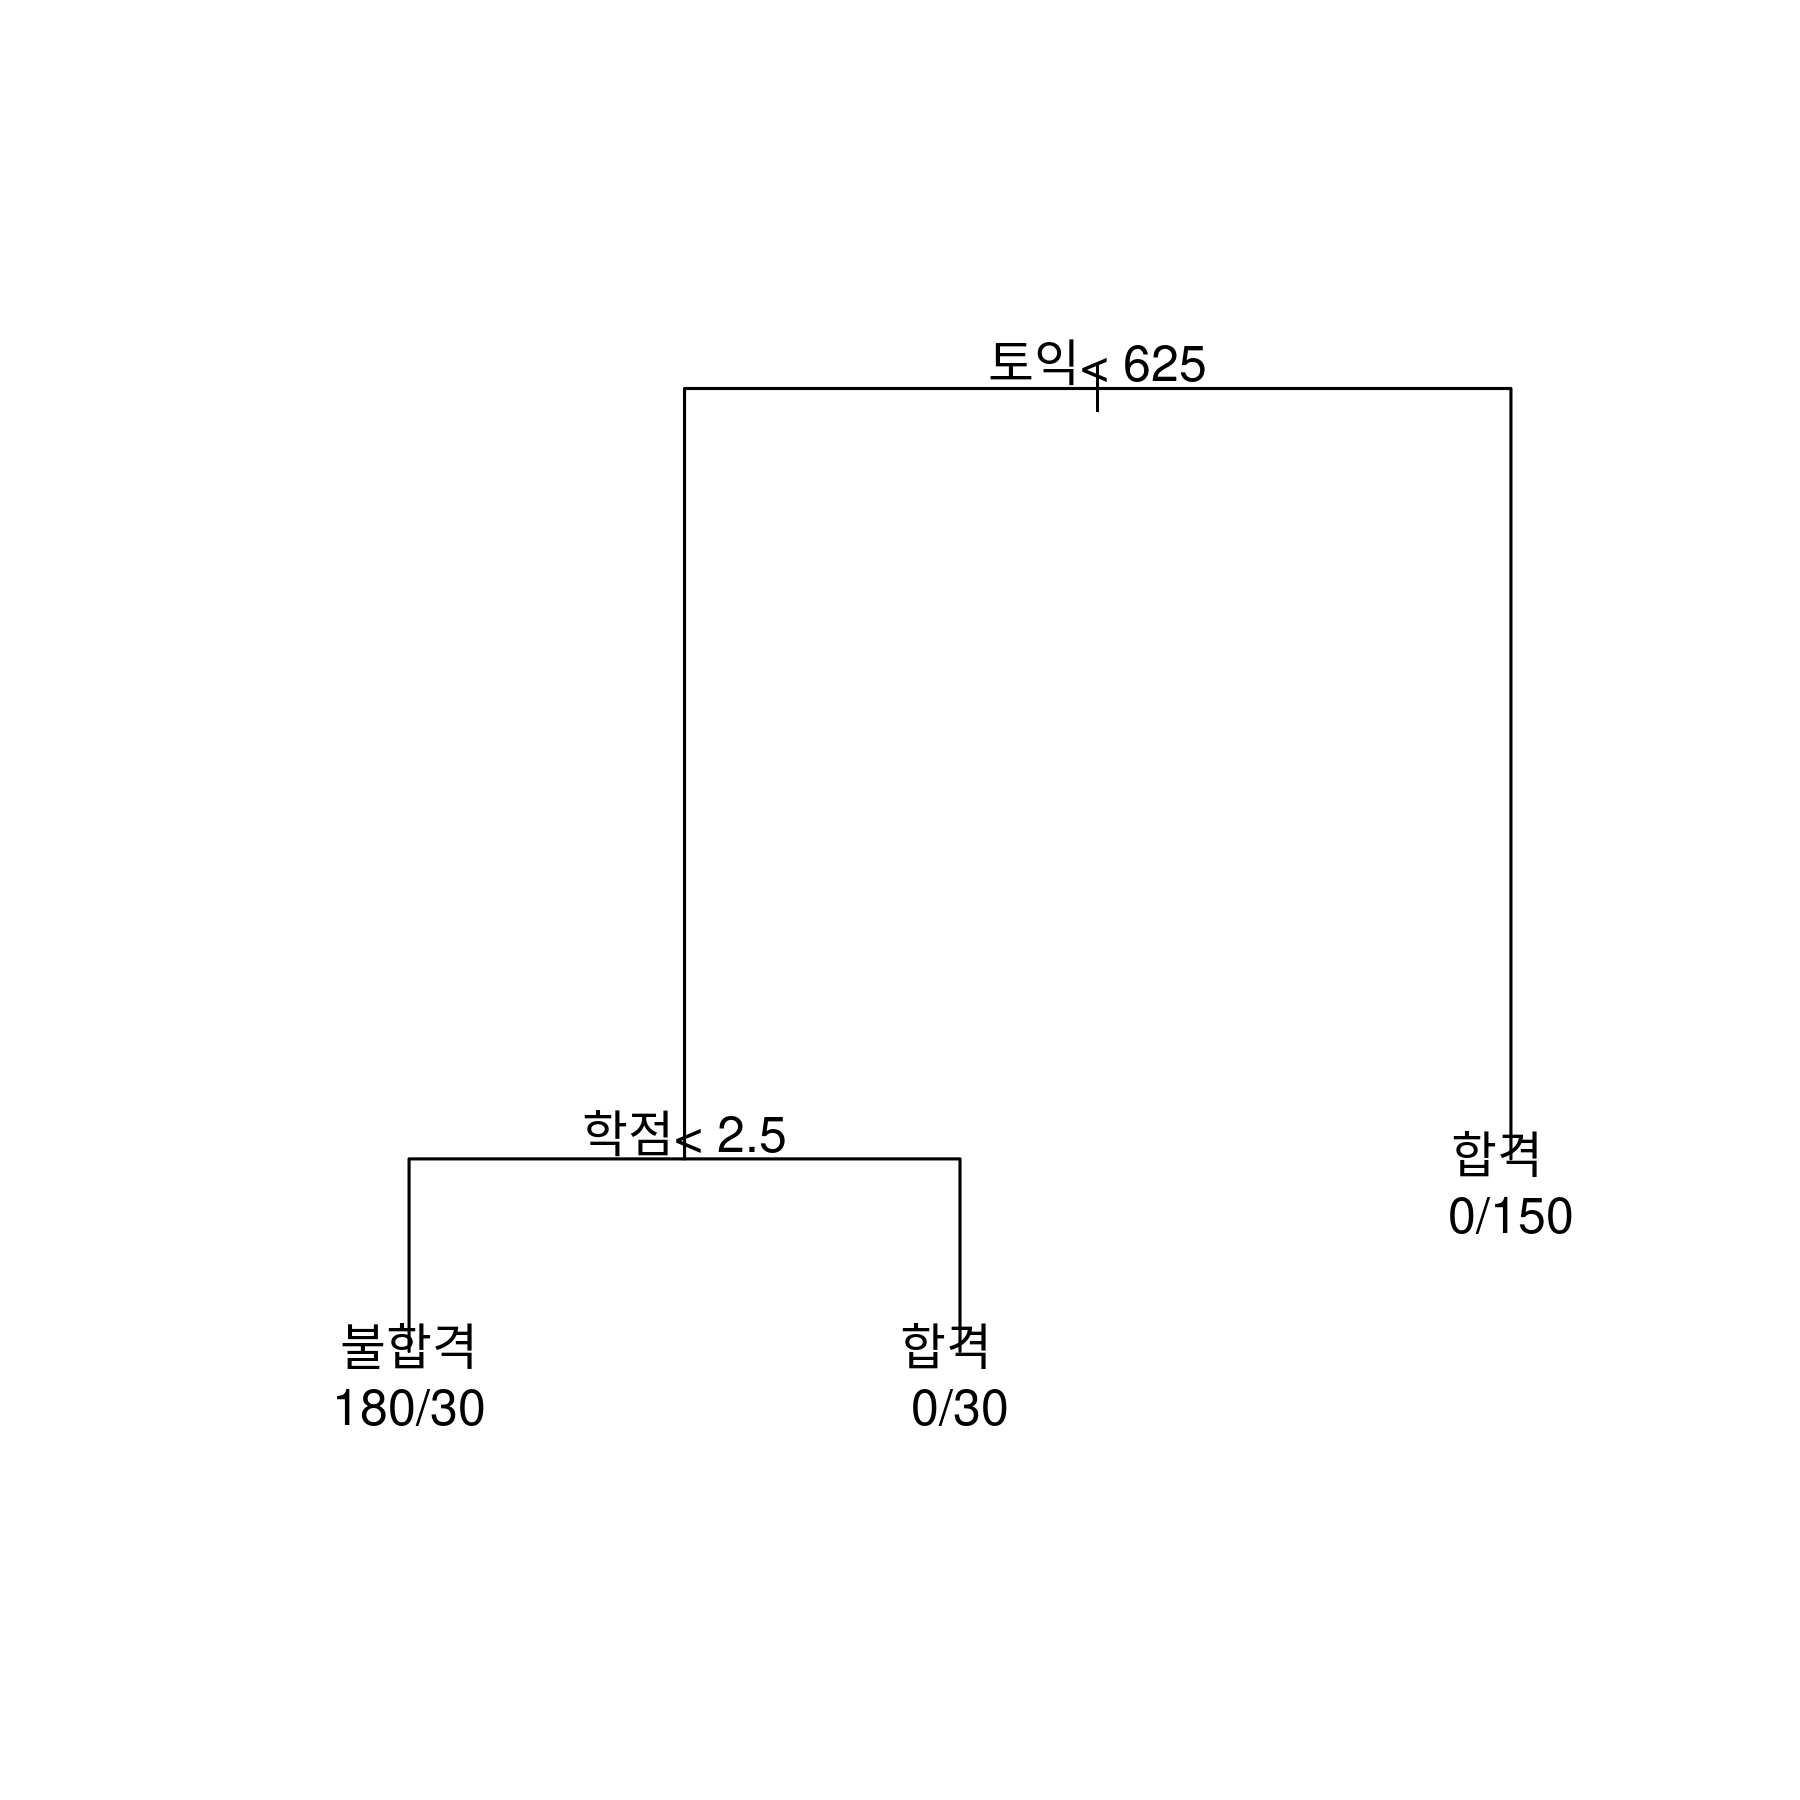

In [29]:
가지를친결과=prune(의사결정나무결과,cp=0.1)
plot(가지를친결과,margin=0.1)
text(가지를친결과,use.n=T)

### 이상치 

`-` 로지스틱회귀

In [30]:
glm(data=데이터2,factor(합격)~토익+학점, family='binomial')


Call:  glm(formula = factor(합격) ~ 토익 + 학점, family = "binomial", 
    data = 데이터2)

Coefficients:
(Intercept)         토익         학점  
  -17.92394      0.02081      3.18837  

Degrees of Freedom: 389 Total (i.e. Null);  387 Residual
Null Deviance:	    538.3 
Residual Deviance: 152.4 	AIC: 158.4

`-` 실수로 데이터 하나를 잘못입력함 

In [31]:
head(데이터2)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,찍먹,먹,홀,홀,짝,홀,짝,짝,홀,홀
2,불합격,350,2,찍먹,안먹,홀,짝,짝,홀,홀,홀,짝,짝
3,불합격,400,1,찍먹,먹,짝,짝,짝,짝,홀,짝,홀,짝
4,불합격,450,2,찍먹,먹,짝,홀,짝,짝,홀,짝,홀,홀
5,불합격,500,2,찍먹,안먹,짝,홀,홀,홀,홀,홀,짝,홀
6,합격,550,3,부먹,먹,짝,홀,홀,짝,홀,홀,짝,홀


In [32]:
데이터2[6,]$토익=-99999

In [33]:
head(데이터2)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,찍먹,먹,홀,홀,짝,홀,짝,짝,홀,홀
2,불합격,350,2,찍먹,안먹,홀,짝,짝,홀,홀,홀,짝,짝
3,불합격,400,1,찍먹,먹,짝,짝,짝,짝,홀,짝,홀,짝
4,불합격,450,2,찍먹,먹,짝,홀,짝,짝,홀,짝,홀,홀
5,불합격,500,2,찍먹,안먹,짝,홀,홀,홀,홀,홀,짝,홀
6,합격,-99999,3,부먹,먹,짝,홀,홀,짝,홀,홀,짝,홀


- 토익이 올라갈수록 합격한다 생각했었음 
- 그런데 토익이 -99999인데 합격인 사람이 발생함
- 컴퓨터는 굉장한 혼란에 빠질것임 

`-` 다시돌려보자. 

In [34]:
glm(data=데이터2,factor(합격)~토익+학점, family='binomial')


Call:  glm(formula = factor(합격) ~ 토익 + 학점, family = "binomial", 
    data = 데이터2)

Coefficients:
(Intercept)         토익         학점  
 -2.804e+00   -2.993e-06    1.308e+00  

Degrees of Freedom: 389 Total (i.e. Null);  387 Residual
Null Deviance:	    538.3 
Residual Deviance: 401.3 	AIC: 407.3

- 토익에 해당하는 계수를 그냥 0으로 만들어버림. $\to$ 토익은 생각 안해
- 모형자체가 확 틀어짐 

`-` 의사결정나무는? 

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 390 180 합격 (0.4615385 0.5384615)  
   2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
     4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571)  
       8) 토익< 475 120   0 불합격 (1.0000000 0.0000000) *
       9) 토익>=475 90  30 불합격 (0.6666667 0.3333333)  
        18) 토익>=525 30   0 불합격 (1.0000000 0.0000000) *
        19) 토익< 525 60  30 불합격 (0.5000000 0.5000000)  
          38) 더미3=짝 31  12 불합격 (0.6129032 0.3870968) *
          39) 더미3=홀 29  11 합격 (0.3793103 0.6206897)  
            78) 민초=안먹 12   4 불합격 (0.6666667 0.3333333) *
            79) 민초=먹 17   3 합격 (0.1764706 0.8235294) *
     5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
   3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

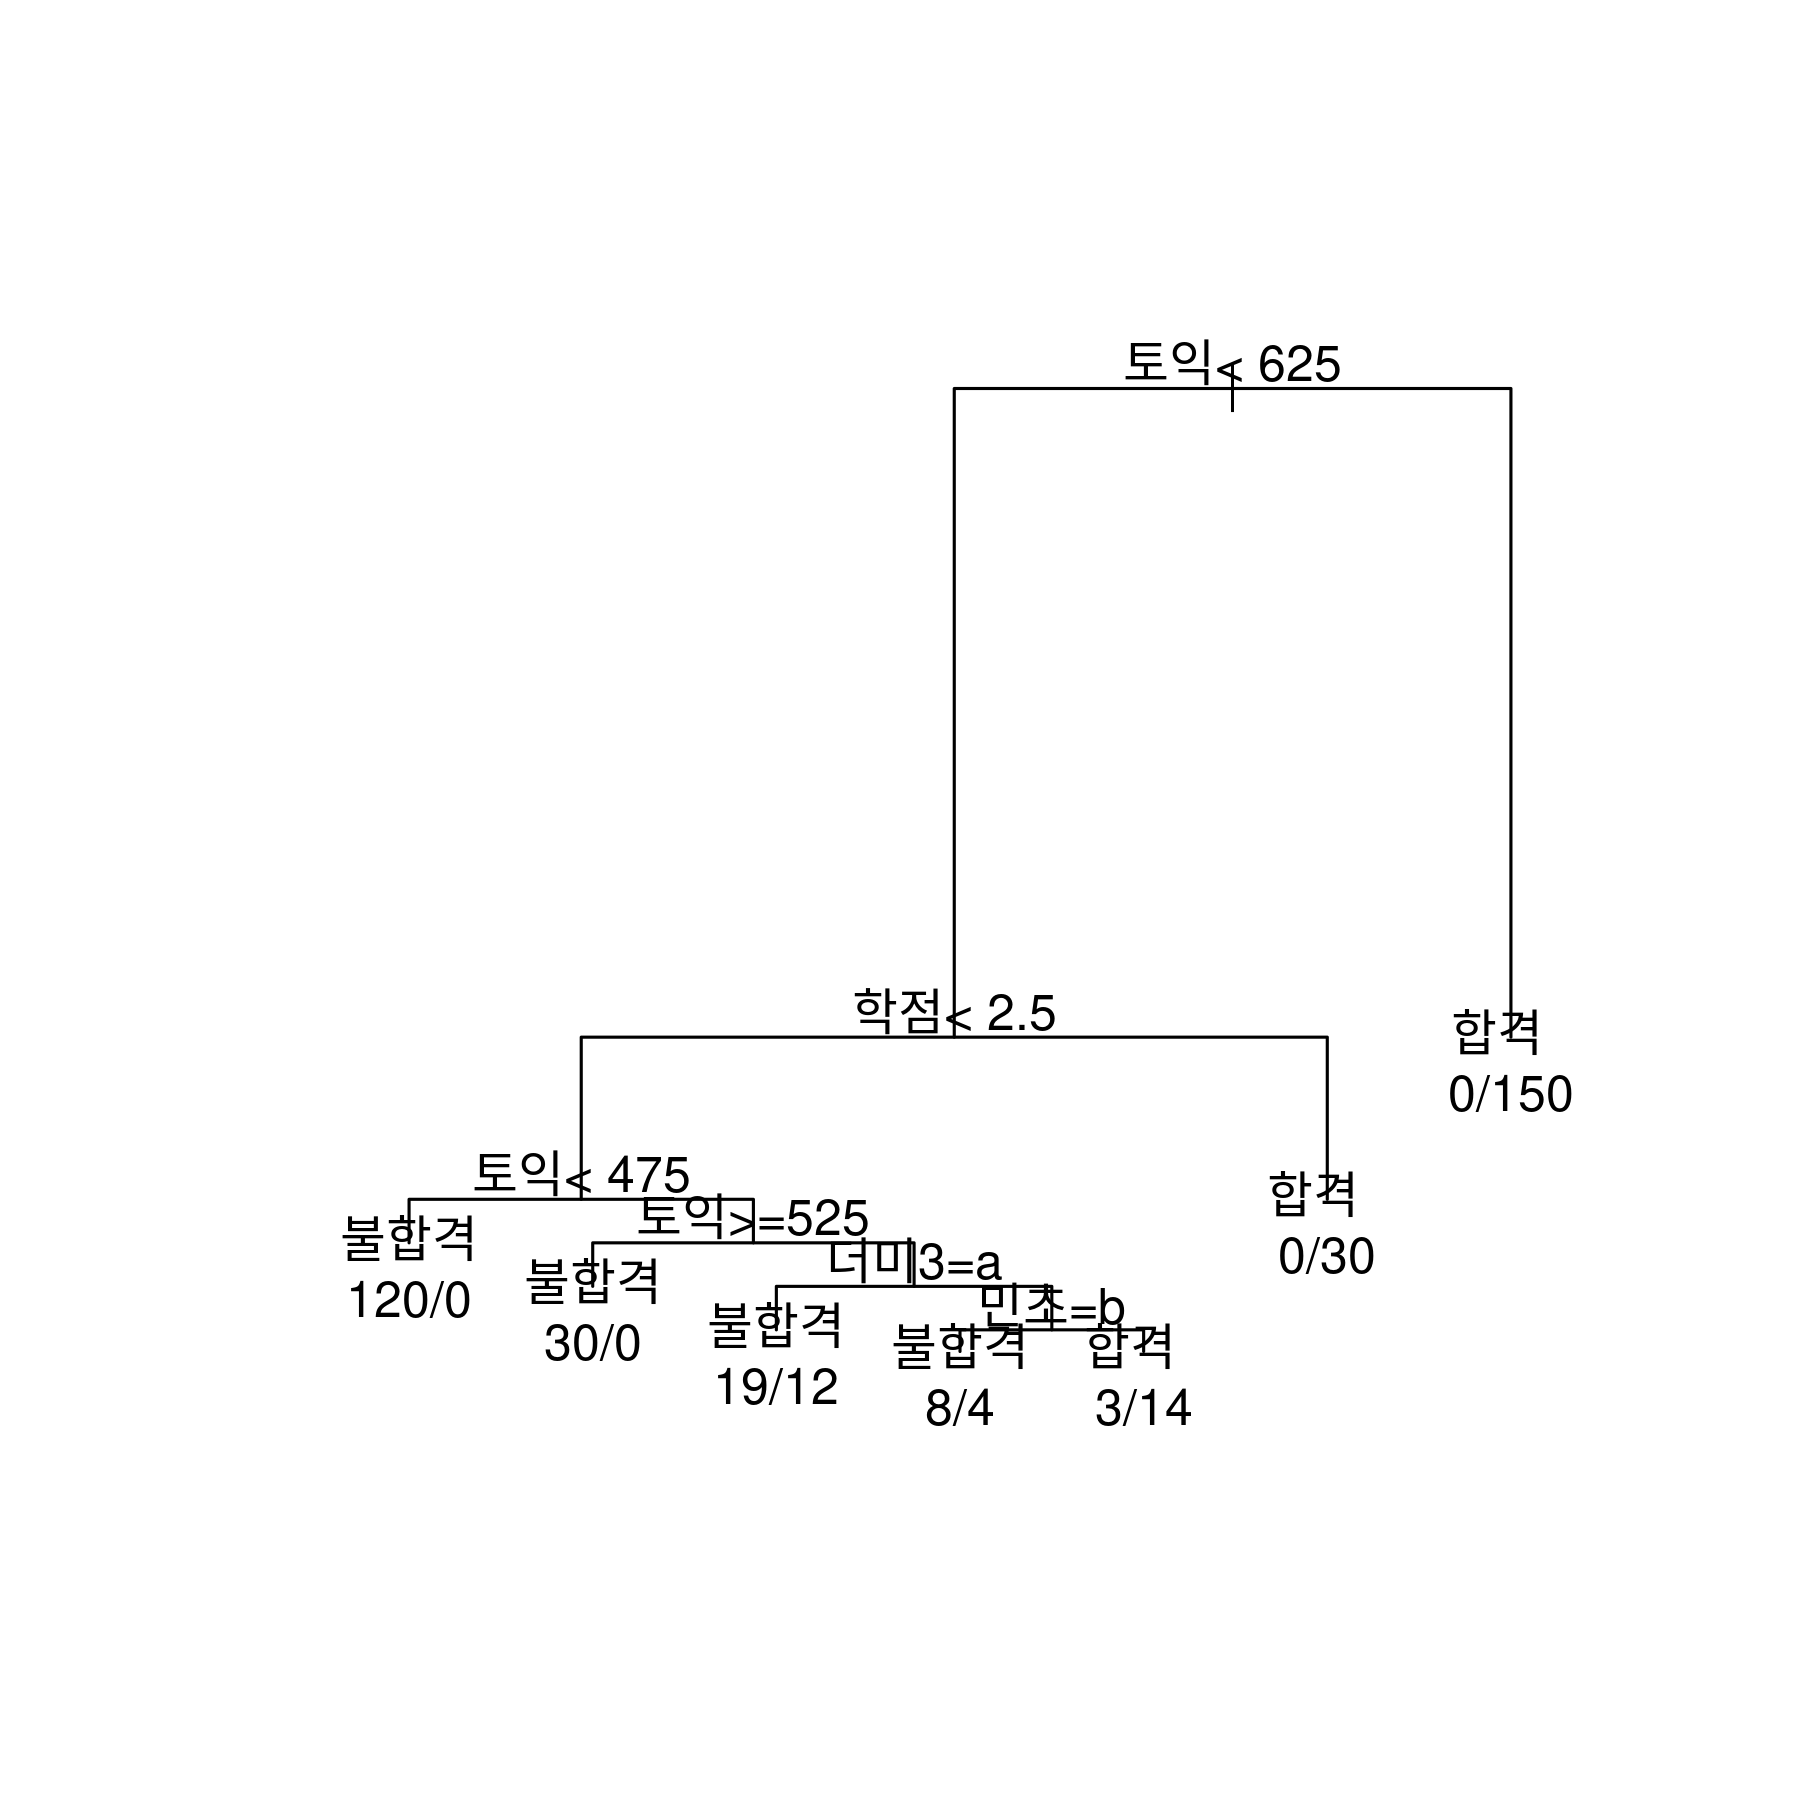

In [35]:
의사결정나무결과=rpart(data=데이터2, 합격~.)
의사결정나무결과
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 별타격없음.. 그냥 분류하나 잘못되는것 뿐임. (불순도가 쥐꼬리 만큼 달라지긴 하겠지) 
- 토익 < 625, 학점 < 2.5 

### 배깅 

`-` 리샘플링기법 

In [36]:
dim(데이터2)

[1] 390  13

In [37]:
샘플링할인덱스=sort(sample(1:390,size=390,replace=T))
샘플링할인덱스

[1]   1   1   3   3   6   6   7   7   7   7  11  12  13  13  13  16  16  16
 [19]  16  18  18  19  23  24  25  26  32  32  32  33  37  38  41  41  42  42
 [37]  42  45  46  46  47  47  48  48  51  52  52  53  54  54  55  56  56  57
 [55]  58  58  60  61  64  66  67  67  67  68  70  72  72  73  74  75  78  78
 [73]  79  79  79  81  81  82  82  82  82  82  83  84  84  86  86  86  87  93
 [91]  94  94  95  95  95  96  97  97 101 102 103 103 106 107 110 111 112 112
[109] 113 114 114 114 115 115 115 116 116 117 118 120 122 122 123 123 124 125
[127] 125 126 127 128 129 130 130 131 132 133 135 136 137 137 138 138 139 139
[145] 140 141 141 143 143 144 145 145 146 148 150 151 152 152 153 153 154 154
[163] 157 159 160 162 162 164 165 165 167 172 173 178 179 179 183 183 183 184
[181] 185 185 189 189 192 194 195 199 199 199 202 202 204 205 206 206 207 207
[199] 208 209 212 213 214 215 215 217 217 217 219 219 219 221 222 223 225 226
[217] 226 228 228 228 229 229 233 235 235 235 235 235 236 238 241 243 243 244
[235] 248 249 252 253 253 254 255 255 257 258 258 258 259 259 259 260 261 261
[253] 261 263 265 266 266 267 267 267 268 269 269 269 269 270 270 270 270 270
[271] 271 271 274 275 275 275 276 276 276 276 277 280 281 281 281 283 284 285
[289] 287 288 288 289 290 293 297 298 298 298 299 300 301 301 302 305 305 305
[307] 306 307 308 308 309 310 310 310 312 312 312 312 312 313 316 316 316 317
[325] 317 319 320 321 321 322 323 325 327 328 329 333 333 333 334 335 337 338
[343] 340 340 343 345 346 347 347 347 348 348 349 351 353 353 354 355 355 355
[361] 356 356 358 358 359 360 363 364 365 367 369 371 373 374 376 377 377 377
[379] 378 379 380 382 382 382 383 383 385 387 387 390

In [38]:
부스트랩=데이터2[샘플링할인덱스,]
head(부스트랩)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,찍먹,먹,홀,홀,짝,홀,짝,짝,홀,홀
1.1,불합격,300,1,찍먹,먹,홀,홀,짝,홀,짝,짝,홀,홀
3,불합격,400,1,찍먹,먹,짝,짝,짝,짝,홀,짝,홀,짝
3.1,불합격,400,1,찍먹,먹,짝,짝,짝,짝,홀,짝,홀,짝
6,합격,-99999,3,부먹,먹,짝,홀,홀,짝,홀,홀,짝,홀
6.1,합격,-99999,3,부먹,먹,짝,홀,홀,짝,홀,홀,짝,홀


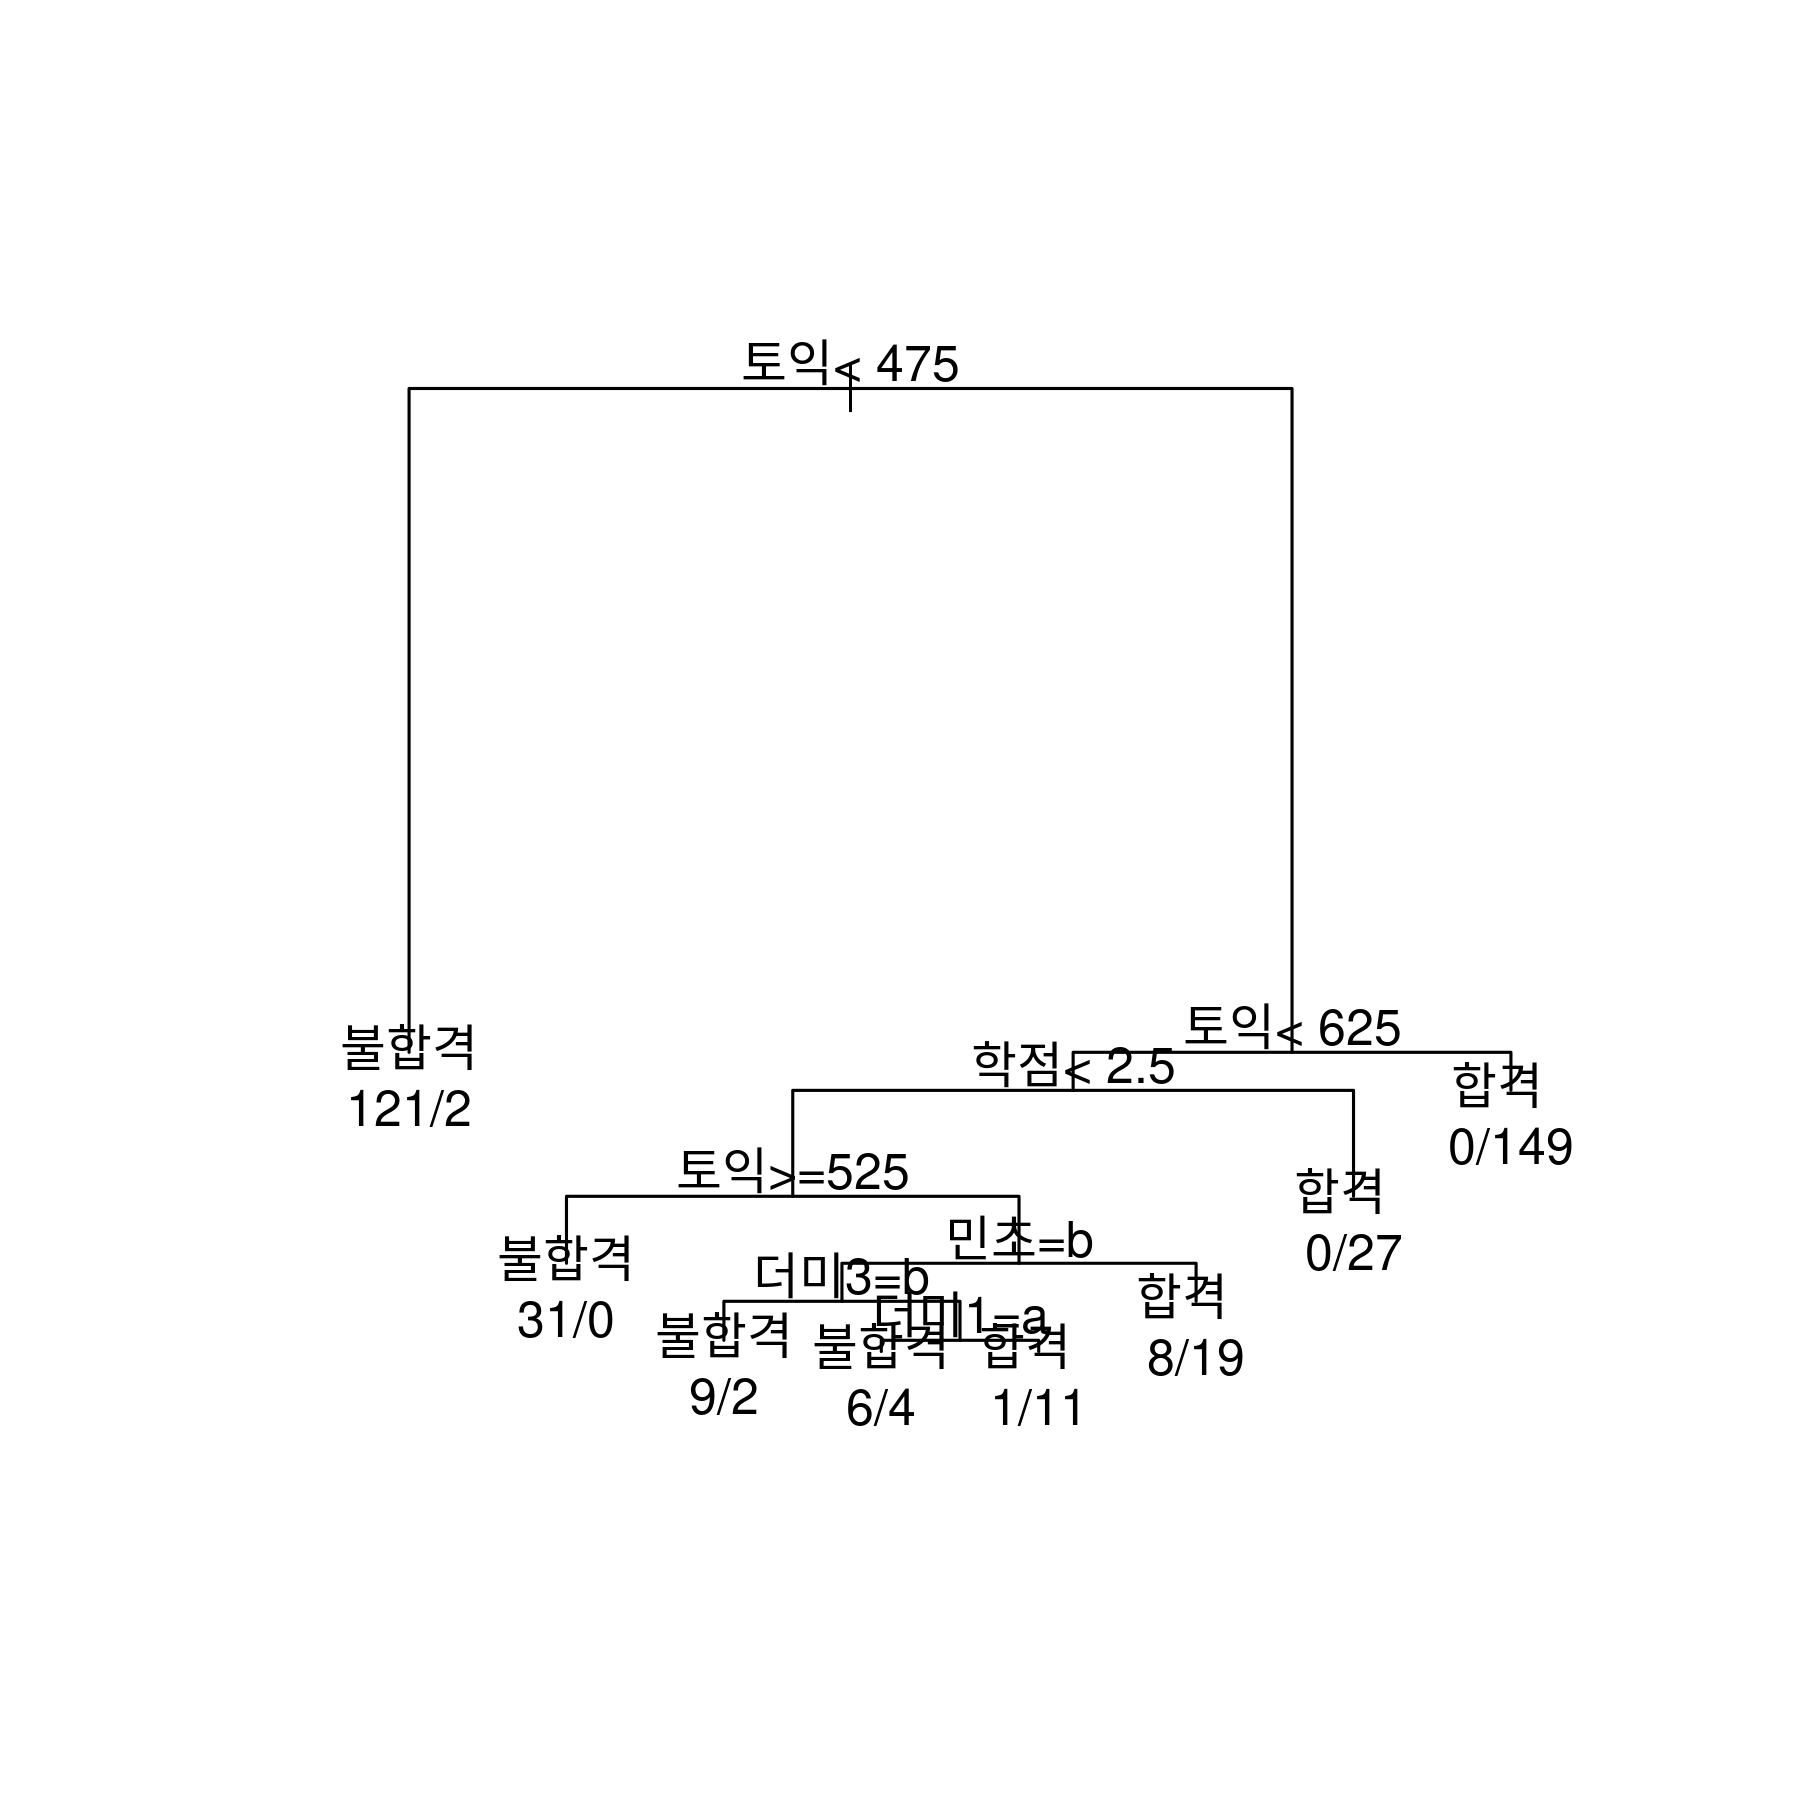

In [39]:
의사결정나무결과=rpart(data=부스트랩, 합격~.)
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

`-` 반복해보자. 

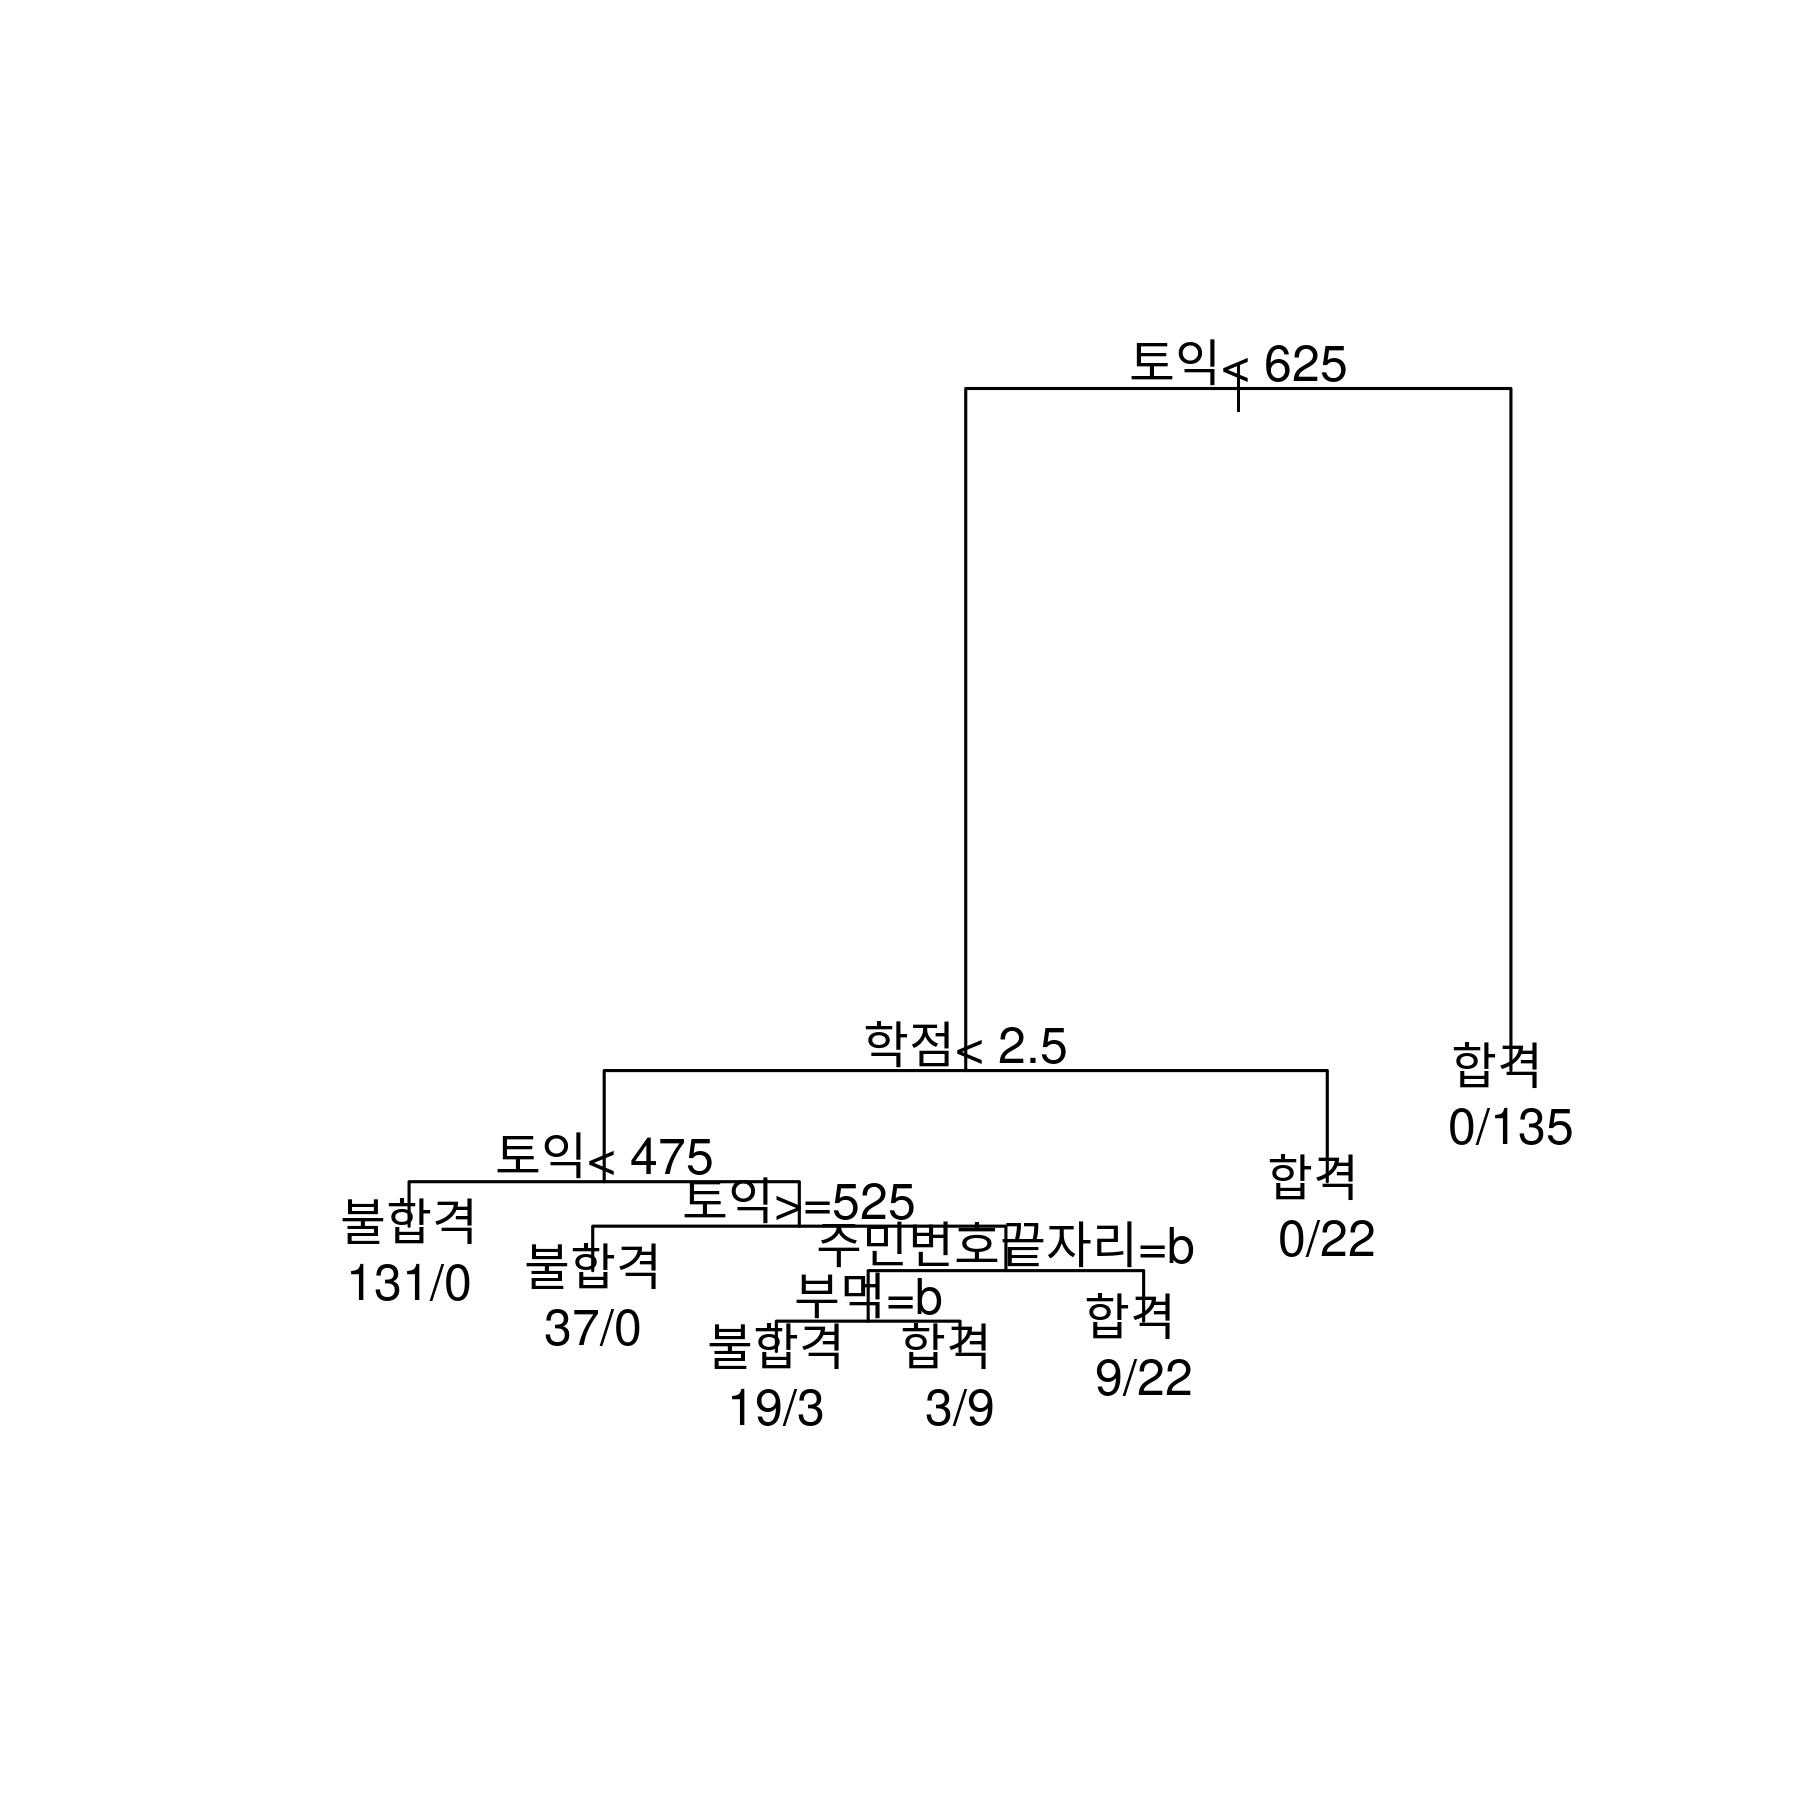

In [40]:
샘플링할인덱스=sort(sample(1:390,size=390,replace=T))
부스트랩=데이터2[샘플링할인덱스,]
의사결정나무결과=rpart(data=부스트랩, 합격~.)
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 다양하네요.. 

### 랜덤포레스트

In [45]:
library(randomForest)

In [48]:
랜덤포레스트결과=randomForest(data=데이터2, factor(합격)~., ntree=100, importance=T)
랜덤포레스트결과


Call:
 randomForest(formula = factor(합격) ~ ., data = 데이터2,      ntree = 100, importance = T) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 3

        OOB estimate of  error rate: 7.69%
Confusion matrix:
       불합격 합격 class.error
불합격    172    8  0.04444444
합격       22  188  0.10476190

In [54]:
importance(랜덤포레스트결과, type=1, scale=FALSE)

,MeanDecreaseAccuracy
토익,1.535318e-01
학점,2.062134e-01
부먹,7.885851e-04
민초,-1.193367e-04
주민번호끝자리,-2.269869e-03
학번끝자리,3.711541e-03
더미1,-1.894165e-03
더미2,-7.206723e-04
더미3,4.410735e-03
더미4,-4.984069e-03


### 나이브베이즈 

`-` 나이브의 뜻: 순진한.. 혹은 단순한 

In [90]:
library(e1071) 

`-` 자료 

In [91]:
데이터[,3] # 5,3,5

[1] 0 0 0 0 0 1 1 0 1 1 1 1 1

In [92]:
공모전=c(rep('N',5),rep('Y',8))
통계복수전공=c(rep('N',8),rep('Y',5))

In [94]:
데이터3=data.frame(합격=c(rep(0,5),c(0,0,1),rep(1,5)), 공모전=공모전, 통계복수전공=통계복수전공) 
데이터3

합격,공모전,통계복수전공
<dbl>,<chr>,<chr>
0,N,N
0,N,N
0,N,N
0,N,N
0,N,N
0,Y,N
0,Y,N
1,Y,N
1,Y,Y


`-` 나이브베이즈

In [95]:
나이브베이즈모델결과 = naiveBayes(합격 ~ ., data = 데이터3)
나이브베이즈모델결과


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
        0         1 
0.5384615 0.4615385 

Conditional probabilities:
   공모전
Y           N         Y
  0 0.7142857 0.2857143
  1 0.0000000 1.0000000

   통계복수전공
Y           N         Y
  0 1.0000000 0.0000000
  1 0.1666667 0.8333333


`-` 예측? 

공모전참고하고, 통계학과복수전공한 학생이 합격할 확률? 

In [96]:
predict(나이브베이즈모델결과,데이터3)

[1] 0 0 0 0 0 0 0 0 1 1 1 1 1
Levels: 0 1

`-` 정리하면 
- 계산을 편하기 하기 위해서 X1, X2는 독립이라는 가정을 한다. (이게 비현실적임) 
- 핵심어: 베이즈이론, 독립 

### KNN, SVM

In [109]:
데이터

토익,학점,y
300,1.0,0
350,2.0,0
400,1.0,0
450,2.0,0
500,2.0,0
550,3.0,1
500,2.0,1
550,2.0,0
750,3.0,1
700,4.0,1


In [111]:
데이터[데이터[,3]==1,]

토익,학점,y
550,3.0,1
500,2.0,1
750,3.0,1
700,4.0,1
750,4.0,1
700,4.0,1
950,0.5,1


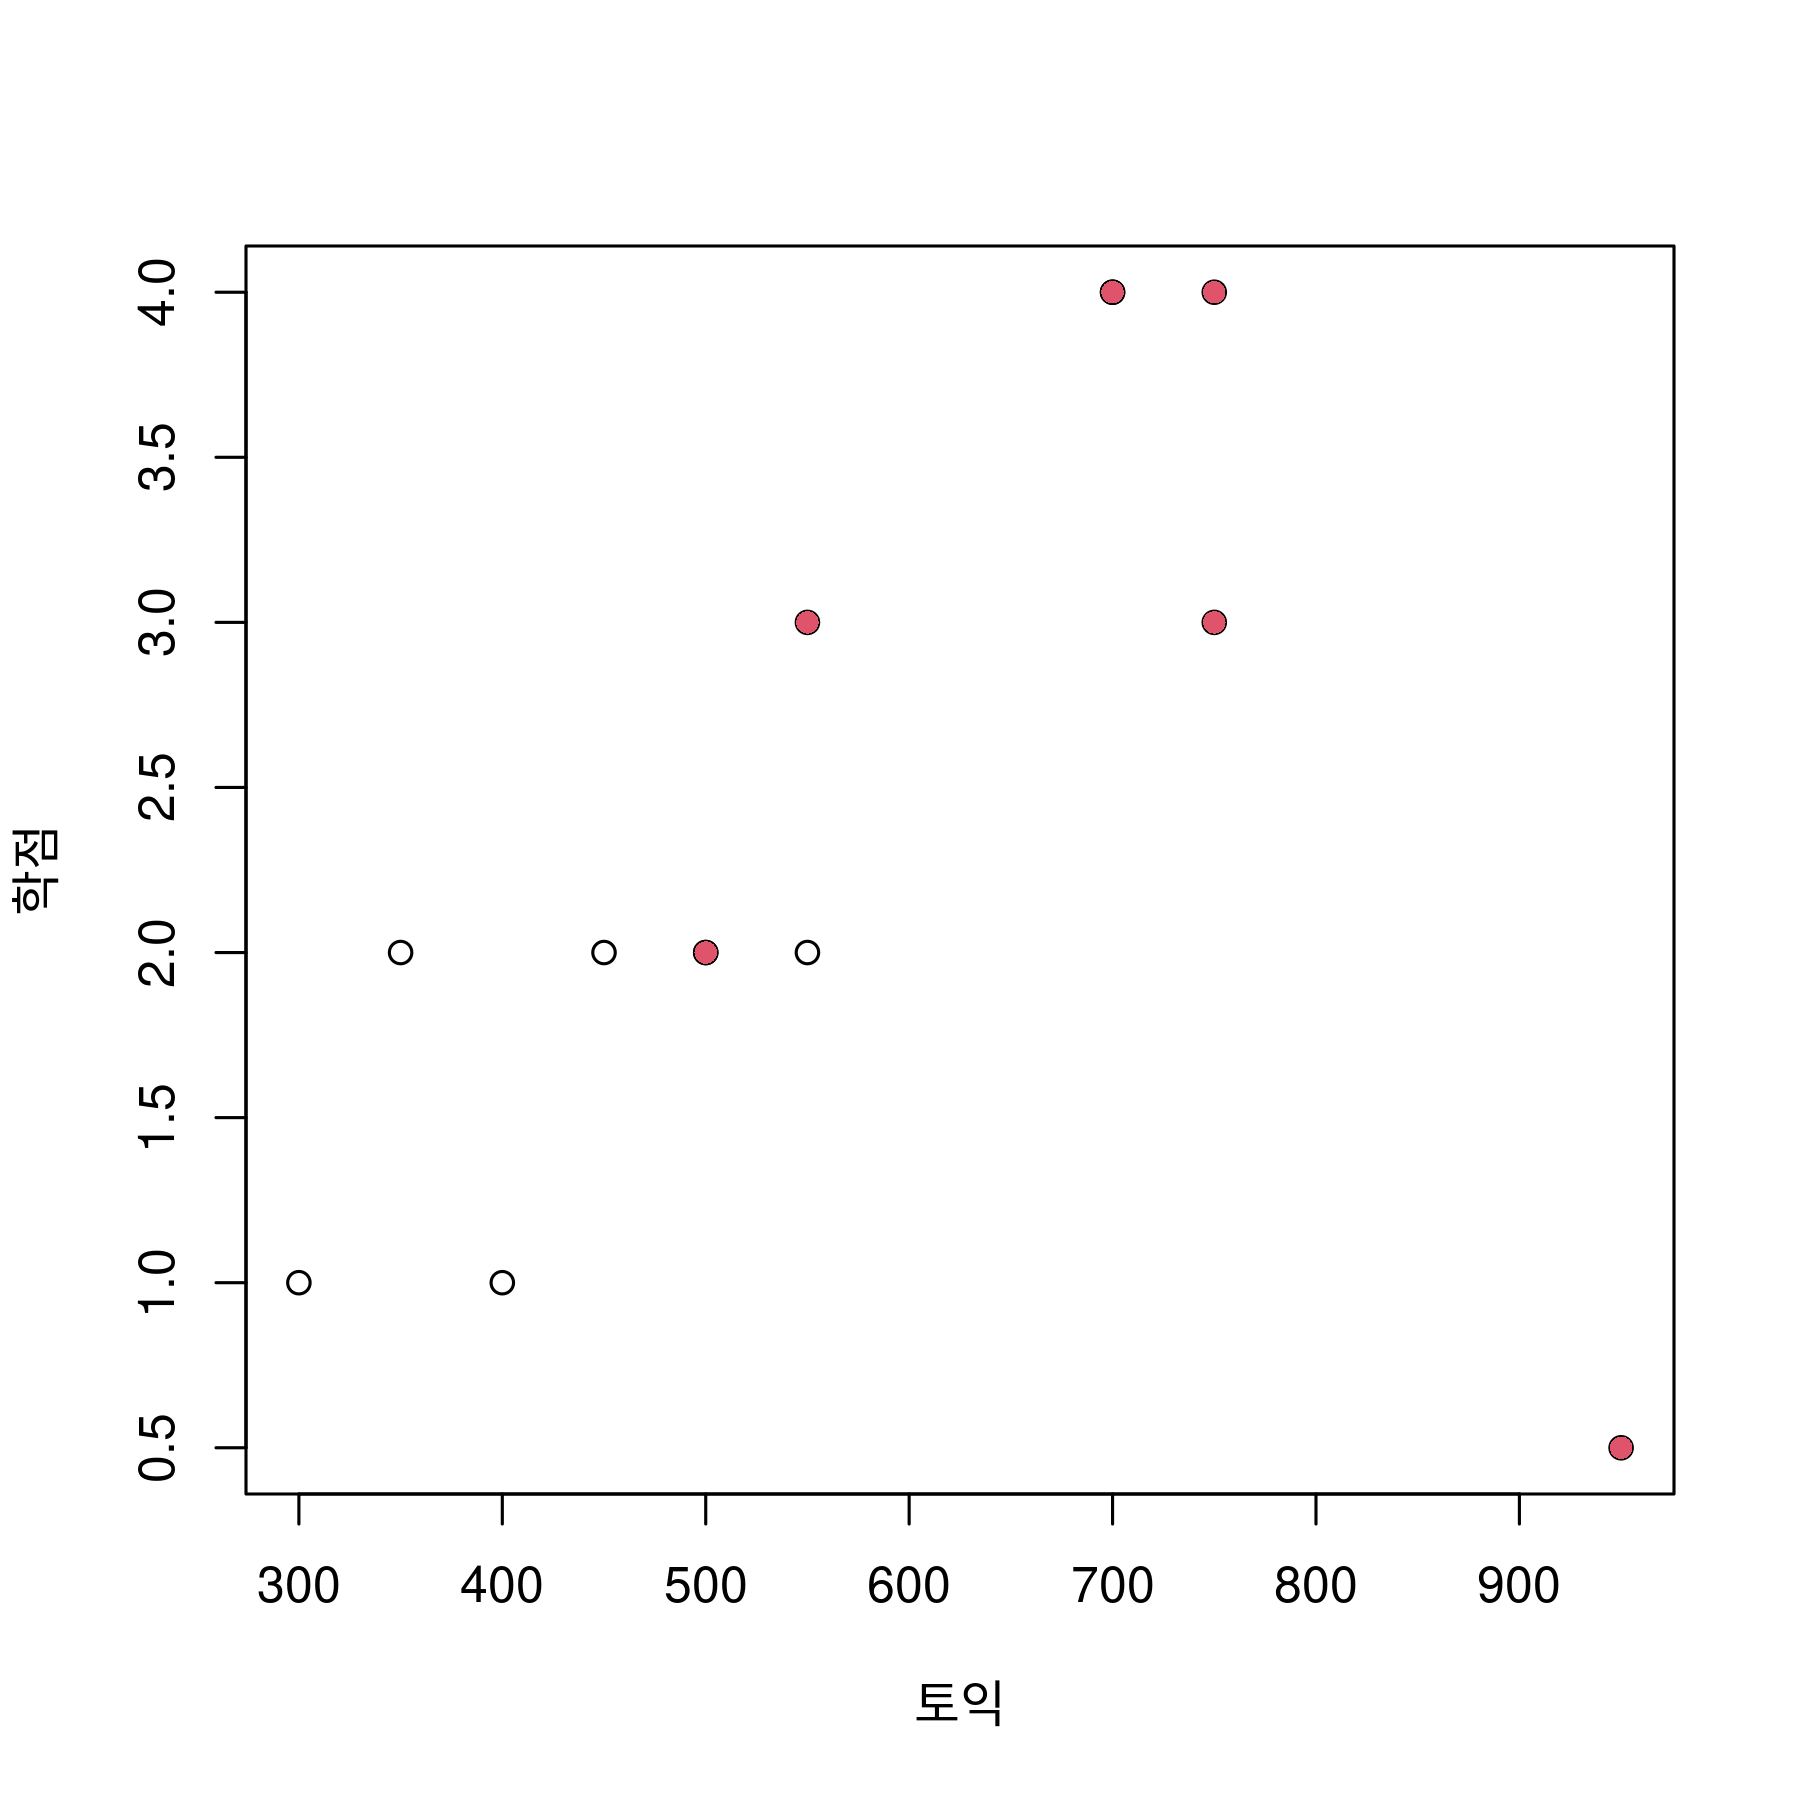

In [115]:
plot(토익,학점)
points(데이터[데이터[,3]==1,][,1],데이터[데이터[,3]==1,][,2],col=2,pch=16)